# Homogeneous Spatiotemporal Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/hpp_spatiotemporal_from_scratch_and_numpyro.ipynb)

A **homogeneous spatiotemporal Poisson process** on $D \times [t_0, t_1)$ with intensity $\lambda > 0$ has count $N \sim \mathrm{Poisson}(\lambda \,|D|\,(t_1-t_0))$, conditional events i.i.d. uniform on the slab, and Janossy log-likelihood $\log L = n \log \lambda - \lambda |D| (t_1 - t_0)$. It is the natural null model in space-time statistics: deviations from this — clusters, pulses, drifts — are what the inhomogeneous and Hawkes-style models in `xtremax` exist to capture.

This notebook walks through both layers of `xtremax` for the spatiotemporal HPP.

1. **From scratch** — pure-JAX primitives (`hpp_spatiotemporal_log_prob`, `hpp_spatiotemporal_sample`).
2. **With NumPyro** — wrap the same process as a `numpyro.distributions.Distribution` and recover $\lambda$ via NUTS.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import RectangularDomain, TemporalDomain
from xtremax.point_processes.distributions import (
    HomogeneousSpatioTemporalPP as HppStDist,
)
from xtremax.point_processes.primitives import (
    hpp_spatiotemporal_log_prob,
    hpp_spatiotemporal_sample,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

Pick a $10 \times 10$ box in space, a 5-unit time window, and intensity $\lambda = 0.5$. Expected count is $\lambda |D| T = 0.5 \cdot 100 \cdot 5 = 250$.

In [2]:
true_rate = 0.5
spatial = RectangularDomain.from_size(jnp.array([10.0, 10.0]))
temporal = TemporalDomain.from_duration(5.0)

key = random.PRNGKey(0)
locations, times, mask, n_uncapped = hpp_spatiotemporal_sample(
    key,
    rate=true_rate,
    spatial=spatial,
    temporal=temporal,
    max_events=512,
)
print(f"Drew {int(mask.sum())} events (uncapped Poisson was {int(n_uncapped)}).")
print(
    f"E[N] = λ |D| T = {true_rate * float(spatial.volume()) * float(temporal.duration):.1f}."
)

Drew 226 events (uncapped Poisson was 226).
E[N] = λ |D| T = 250.0.


Visualise the realisation as a space-time scatter — colour encodes time so the temporal evolution is visible at a glance.

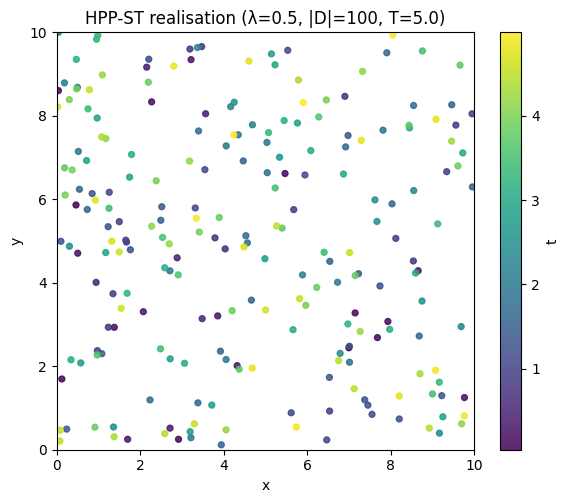

In [3]:
real_locs = locations[mask]
real_times = times[mask]
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    real_locs[:, 0], real_locs[:, 1], c=real_times, s=18, alpha=0.85, cmap="viridis"
)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    f"HPP-ST realisation (λ={true_rate}, |D|={int(spatial.volume())}, T={float(temporal.duration):.1f})"
)
plt.colorbar(sc, ax=ax, label="t")
plt.tight_layout()
plt.show()

### Log-likelihood

The Janossy form drops the $-\log(n!)$ count normaliser and the iid-uniform $-n \log(|D| T)$ location density — same convention as the inhomogeneous spatiotemporal log-prob, so they compose.

In [4]:
n_events = jnp.sum(mask).astype(jnp.int32)
log_p = hpp_spatiotemporal_log_prob(
    n_events, true_rate, spatial.volume(), temporal.duration
)
print(f"log L = {float(log_p):.3f}")

log L = -406.651


## 2. With NumPyro — recover λ from a single realisation

We treat the count as the sufficient statistic for $\lambda$ and run NUTS. Use a weakly-informative log-normal prior so the posterior reflects the data rather than the prior.

In [5]:
spp = HppStDist(rate=true_rate, spatial=spatial, temporal=temporal, max_events=512)
locs_obs, times_obs, mask_obs = spp.sample(random.PRNGKey(1))
n_obs = int(jnp.sum(mask_obs))
print(f"Observed n = {n_obs}")


def model(n_obs, spatial, temporal):
    rate = numpyro.sample("rate", dist.LogNormal(loc=0.0, scale=1.0))
    spp = HppStDist(rate=rate, spatial=spatial, temporal=temporal)
    fake_locs = jnp.zeros((spp.max_events, spatial.n_dims))
    fake_times = jnp.zeros((spp.max_events,))
    numpyro.factor("lik", spp.log_prob((fake_locs, fake_times, jnp.asarray(n_obs))))


mcmc = MCMC(
    NUTS(model), num_warmup=300, num_samples=600, num_chains=1, progress_bar=False
)
mcmc.run(random.PRNGKey(2), n_obs=n_obs, spatial=spatial, temporal=temporal)
posterior = mcmc.get_samples()["rate"]
print(f"Posterior mean: {float(jnp.mean(posterior)):.3f}, true: {true_rate}")
print(
    f"Posterior 95% CI: [{float(jnp.quantile(posterior, 0.025)):.3f}, {float(jnp.quantile(posterior, 0.975)):.3f}]"
)

Observed n = 267


Posterior mean: 0.535, true: 0.5
Posterior 95% CI: [0.476, 0.593]


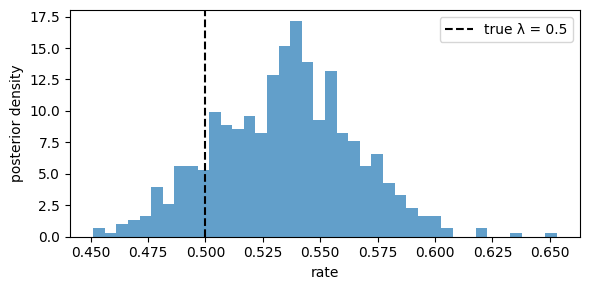

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(posterior, bins=40, density=True, alpha=0.7, color="C0")
ax.axvline(true_rate, color="k", linestyle="--", label=f"true λ = {true_rate}")
ax.set_xlabel("rate")
ax.set_ylabel("posterior density")
ax.legend()
plt.tight_layout()
plt.show()

The 95% CI tightens around the true rate as $T$ or $|D|$ grows — the count alone determines $\lambda$ via the Poisson sufficiency, and the posterior precision scales with $\sqrt{\lambda |D| T}$.